In [1]:
# libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from sklearn.feature_selection import mutual_info_classif, f_classif, chi2
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.feature_selection import SelectKBest, RFE, SelectFromModel
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import urllib.request
import os
from IPython.display import Audio, display


## 1. Exploratory Analysis and Data Cleaning

## EDA

In [2]:
# Load dataset

df = sns.load_dataset('titanic')
print(df.shape)

(891, 15)


In [108]:
# Print 5 rows

df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [109]:
# print information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [110]:
# print numerical columns data

df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [111]:
# count numbers of each value in 'sex' column 

df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In the EDA part, we first analysed the shape of the dataset, took a look at the columns of the data and then checked some numerical data about each column, such as mean, min, max, ... , also we checked the number of non-null data in each column to examine how much data is missing.

## Data cleaning

In [59]:
# count the number of Nan values

df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [60]:
# print the rows with Nan in 'age' , 'deck' columns

df[df['age'].isnull() | df['deck'].isnull()].loc[1:10]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [61]:
# print last 10 rows with Nan in 'age' , 'deck' columns

df[df['age'].isnull() | df['deck'].isnull()].tail(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
878,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
881,0,3,male,33.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True
883,0,2,male,28.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
890,0,3,male,32.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True


In [3]:
# handling missing data and redundancy

df.drop(['deck'], axis=1, inplace=True)
print("Dropped 'deck' column due to excessive missing values.")

median_age = df['age'].median()
df['age'].fillna(median_age, inplace=True)
print("Age null values were filled with the median age.")

mode_embarked = df['embarked'].mode()[0]
df['embarked'].fillna(mode_embarked, inplace=True)
print("Embarked null values were filled with the mode embark.")

columns_to_drop = ['alive', 'who', 'adult_male', 'class', 'embark_town']
df.drop(columns_to_drop, axis=1, inplace=True, errors='ignore')
print("Dropped 'alive', 'who', 'adult_male', 'class', 'embark_town' columns due to redundancy.")


Dropped 'deck' column due to excessive missing values.
Age null values were filled with the median age.
Embarked null values were filled with the mode embark.
Dropped 'alive', 'who', 'adult_male', 'class', 'embark_town' columns due to redundancy.


C:\Users\melin\AppData\Local\Temp\ipykernel_22384\793213430.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(median_age, inplace=True)
C:\Users\melin\AppData\Local\Temp\ipykernel_22384\793213430.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [63]:
print(df.shape)

(891, 9)


In [64]:
# check all null values are handled

df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

In [65]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [66]:
df[df['age'] == 0.42]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
803,1,3,male,0.42,0,1,8.5167,C,False


>This row data is not invalid, 0.42 for age is around 5 months and also It's historically accurate that there were infants on the Titanic.

In [67]:
df[df['fare'] == 0]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
179,0,3,male,36.0,0,0,0.0,S,True
263,0,1,male,40.0,0,0,0.0,S,True
271,1,3,male,25.0,0,0,0.0,S,True
277,0,2,male,28.0,0,0,0.0,S,True
302,0,3,male,19.0,0,0,0.0,S,True
413,0,2,male,28.0,0,0,0.0,S,True
466,0,2,male,28.0,0,0,0.0,S,True
481,0,2,male,28.0,0,0,0.0,S,True
597,0,3,male,49.0,0,0,0.0,S,True
633,0,1,male,28.0,0,0,0.0,S,True


These zero-fare passengers generally fall into **two categories**:

1. Crew Members, Musicians, and Shipyard Employees
- In some versions of the dataset, the fare column is set to 0 to clearly indicate that the person was **not a regular passenger** who paid for a ticket
- The crew and other staff were **working on the ship**, not traveling as paying customers

2. Passengers with Complimentary (Free) Tickets
- Historical records show that a small group of **8 musicians** and **9 shipyard employees** were listed as passengers
- They traveled on **complimentary tickets**, meaning they also did not pay a fare

> These zero fares are not invalid data - they represent legitimate individuals on the ship who didn't pay for passage.


In [113]:
# handling other invalid data

invalid_ages = df[(df['age'] < 0) | (df['age'] > 100)]
print(f"Impossible ages (negative or >100): {len(invalid_ages)}")

if len(invalid_ages) > 0:
    print(invalid_ages[['age', 'survived']])


invalid_fares = df[df['fare'] < 0]
print(f"\nNegative fares: {len(invalid_fares)}")


Impossible ages (negative or >100): 0

Negative fares: 0


In [4]:
# handling duplicate data

duplicates = df.duplicated()
print(f"\nDuplicate rows: {duplicates.sum()}")

df = df.drop_duplicates()
print("Duplicated rows were deleted.")

print(df.shape)


Duplicate rows: 116
Duplicated rows were deleted.
(775, 9)


In [115]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In the data cleaning section, first we checked the total missing data in each column and then tried to handle the missing data, for the 'deck' column, the amount of missing data was huge, so it was better to drop the column. For the 'age' column, as the data was valuable for further analysis, we filled the null values with the median age. For the 'embarked' column, we filled the null values with the mode embark. In the end we dropped other columns that didn't contain new information and were redundant.

Then we checked the invalid data, taking a look at the output of df.describe, two columns were suspicious, first the age 0.42 and fare values equal to 0, we checked for their validity as explained before and also made sure about other values of the 'age' and 'fare' column by testing some inequalitites about negative fare and more than 100 years and less that 0 year for age.

Then we went through duplcate data, and drop their rows because we didn't need them and they could badly affect the analysis.

## Preprocessing

In [5]:
# check for non-numerical columns

non_numeric_cols = df.select_dtypes(exclude=['number']).columns.tolist()
print("Non-numerical columns:", non_numeric_cols)

Non-numerical columns: ['sex', 'embarked', 'alone']


In [6]:
# transform non-numerical columns to numeric

to_categorical_columns=['sex', 'embarked', 'alone']

for column in to_categorical_columns:
    df[column] = df[column].astype('category').cat.codes

print("\nTransformed 'sex' (0=Female, 1=Male):")

print("\nTransformed 'embarked' (0=C, 1=Q, 2=S):")

print("\nTransformed 'alone' (0=False, 1=True):")

df.head(5)



Transformed 'sex' (0=Female, 1=Male):

Transformed 'embarked' (0=C, 1=Q, 2=S):

Transformed 'alone' (0=False, 1=True):


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,0
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,2,1
3,1,1,0,35.0,1,0,53.1000,2,0
4,0,3,1,35.0,0,0,8.0500,2,1


In this section we checked the columns with non-numerical values, and then converted them to numerical values by assigning some numbers to each type in each column.

## Normalization

In [7]:
# normalizing

# keep original
df['age_years'] = df['age']  
df['fare_dollars'] = df['fare'] 

scaler = StandardScaler()
standard_scaling_columns = ['fare', 'age']
df[standard_scaling_columns] = scaler.fit_transform(df[standard_scaling_columns])
df[standard_scaling_columns].describe()

,fare,age
count,7.750000e+02,7.750000e+02
mean,-1.134576e-16,2.521281e-16
std,1.000646e+00,1.000646e+00
min,-6.659405e-01,-2.119661e+00
25%,-5.122402e-01,-6.237473e-01
50%,-3.623586e-01,-1.149330e-01
75%,-1.299298e-02,4.665691e-01
max,9.116066e+00,3.664831e+00


In [74]:
# calculate correlation

corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,age_years,fare_dollars
survived,1.000000,-0.331388,-0.516121,-0.078114,-0.037841,0.069864,0.247159,-0.156272,-0.176714,-0.078114,0.247159
pclass,-0.331388,1.000000,0.118507,-0.342745,0.087050,0.038998,-0.554649,0.179630,0.113778,-0.342745,-0.554649
sex,-0.516121,0.118507,1.000000,0.093574,-0.095574,-0.235116,-0.168979,0.096974,0.277339,0.093574,-0.168979
age,-0.078114,-0.342745,0.093574,1.000000,-0.279316,-0.182697,0.092503,-0.025019,0.190270,1.000000,0.092503
sibsp,-0.037841,0.087050,-0.095574,-0.279316,1.000000,0.379535,0.133807,0.065823,-0.607809,-0.279316,0.133807
parch,0.069864,0.038998,-0.235116,-0.182697,0.379535,1.000000,0.190823,0.045362,-0.569387,-0.182697,0.190823
fare,0.247159,-0.554649,-0.168979,0.092503,0.133807,0.190823,1.000000,-0.237438,-0.245168,0.092503,1.000000
embarked,-0.156272,0.179630,0.096974,-0.025019,0.065823,0.045362,-0.237438,1.000000,0.059749,-0.025019,-0.237438
alone,-0.176714,0.113778,0.277339,0.190270,-0.607809,-0.569387,-0.245168,0.059749,1.000000,0.190270,-0.245168
age_years,-0.078114,-0.342745,0.093574,1.000000,-0.279316,-0.182697,0.092503,-0.025019,0.190270,1.000000,0.092503


In this section we normalised the 'age' and 'fare' column using standard scaler and then looked at the correlation between each column.

## 2. Data Visualization

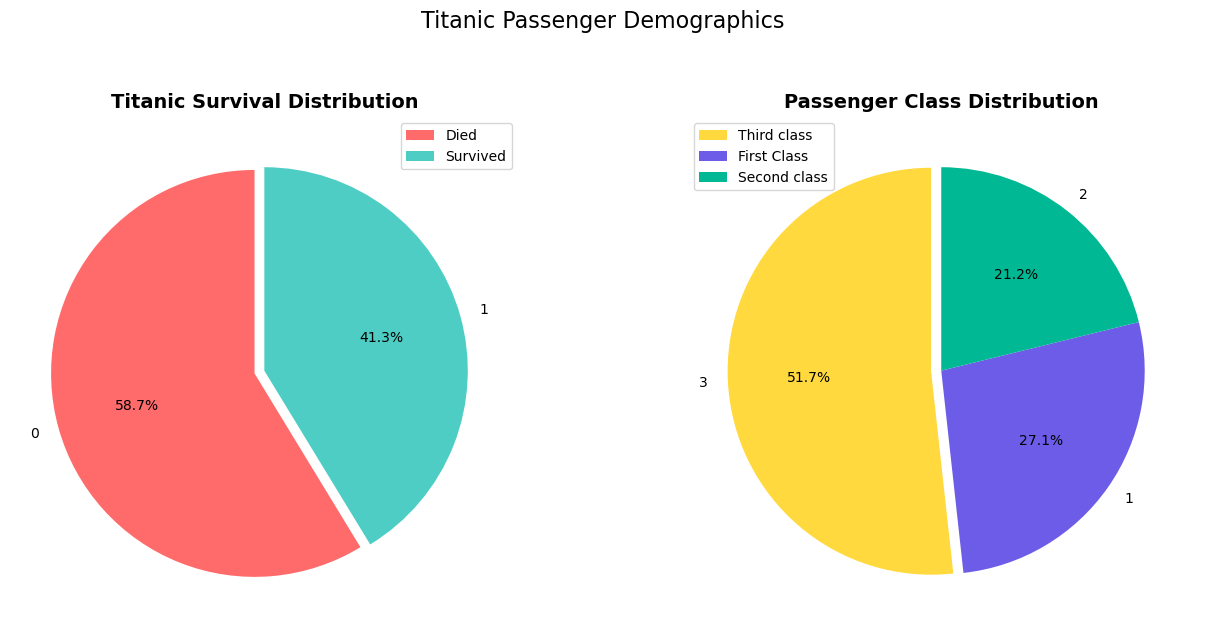

In [75]:
# Pie Chart

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Survival counts
survival_counts = df['survived'].value_counts()
axes[0].pie(survival_counts.values, labels=survival_counts.index, 
            autopct='%1.1f%%', colors=['#ff6b6b', '#4ecdc4'], explode=(0.05, 0), startangle=90)
axes[0].set_title('Titanic Survival Distribution', fontsize=14, fontweight='bold')
axes[0].legend(['Died', 'Survived'])

# Subplot 2: Passenger Class distribution
class_counts = df['pclass'].value_counts()
colors_class = ['#ffd93d', '#6c5ce7', '#00b894']
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', colors=colors_class, 
            explode=(0.05, 0, 0), startangle=90)
axes[1].set_title('Passenger Class Distribution', fontsize=14, fontweight='bold')
axes[1].legend(['Third class', 'First Class', 'Second class'])

plt.suptitle('Titanic Passenger Demographics', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

C:\Users\melin\AppData\Local\Temp\ipykernel_21072\236333288.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='age_years', data=df, ax=axes, palette=['#ff6b6b', '#4ecdc4'])
C:\Users\melin\AppData\Local\Temp\ipykernel_21072\236333288.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(['Died', 'Survived'])


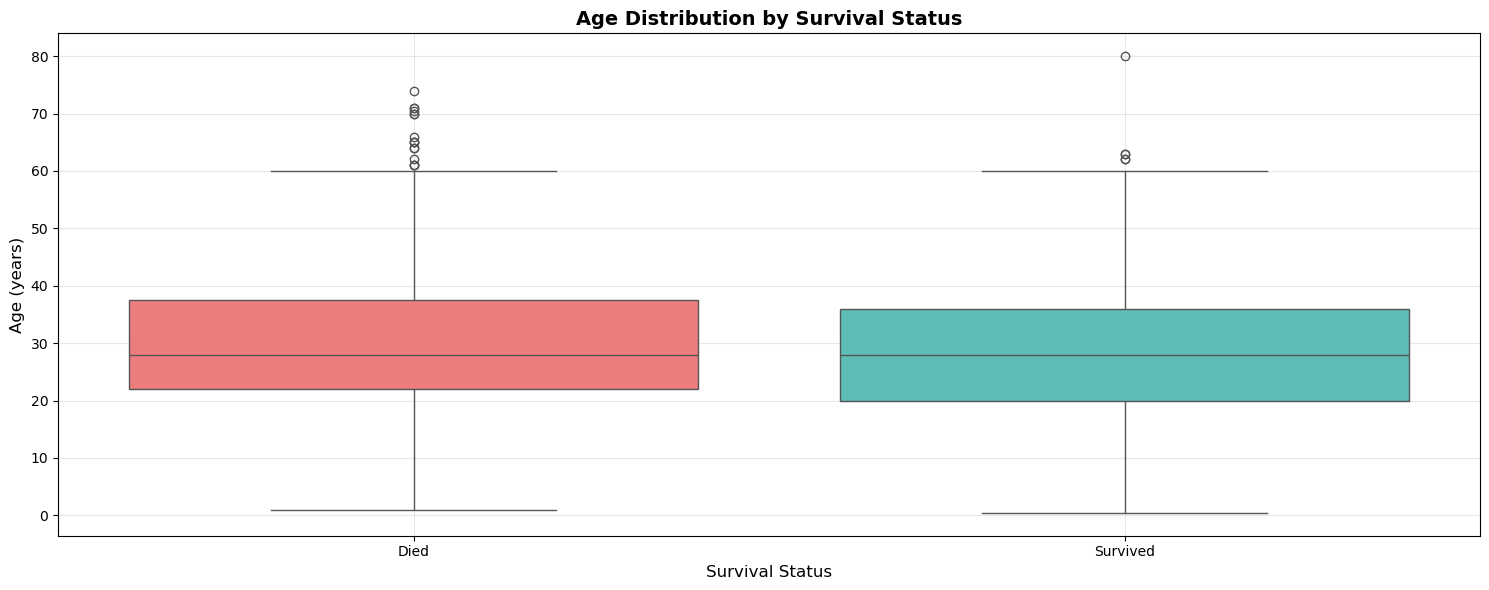

In [76]:
# Box Plot 

fig, axes = plt.subplots(1, 1, figsize=(15, 6))

# Box plot: Age vs Survival
sns.boxplot(x='survived', y='age_years', data=df, ax=axes, palette=['#ff6b6b', '#4ecdc4'])
axes.set_title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
axes.set_xlabel('Survival Status', fontsize=12)
axes.set_xticklabels(['Died', 'Survived'])
axes.set_ylabel('Age (years)', fontsize=12)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

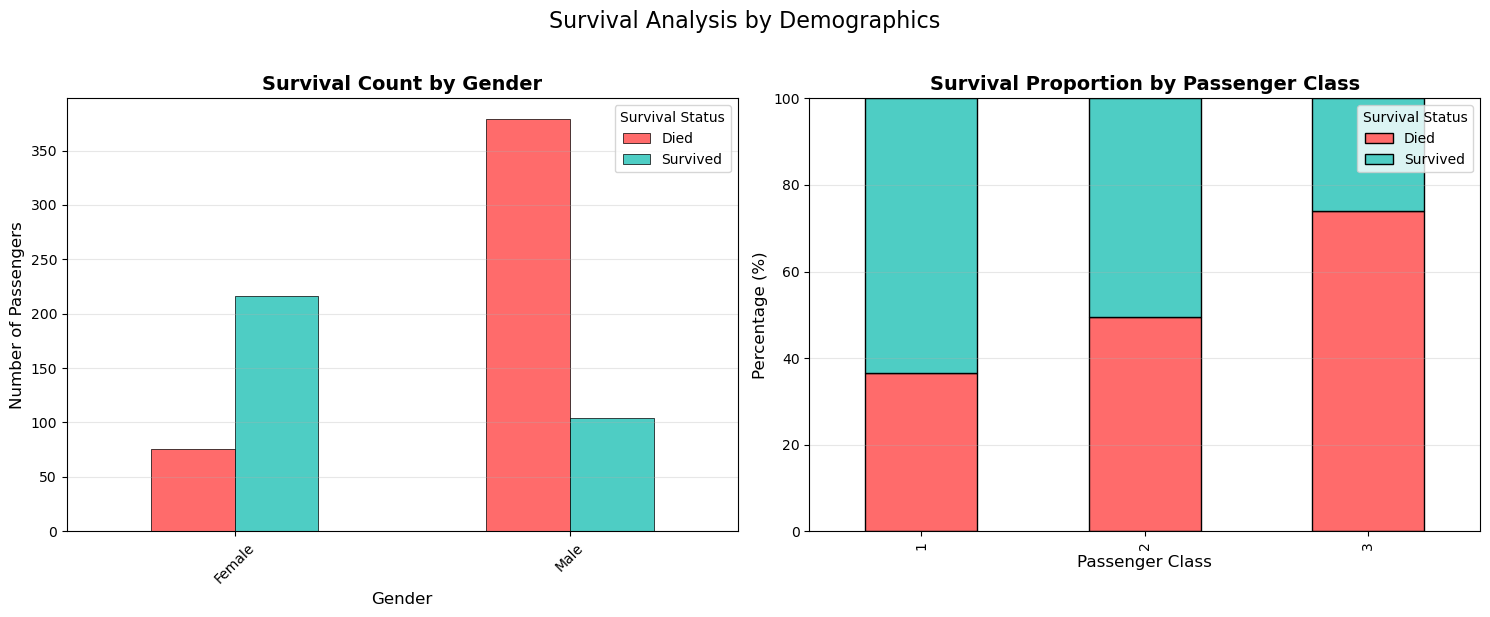

In [77]:
# Bar Chart 1

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar Chart: Survival by gender
survival_data = pd.crosstab(df['sex'], df['survived'])
survival_data.plot(kind='bar', ax=axes[0], color=['#ff6b6b', '#4ecdc4'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Survival Count by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_xticklabels(['Female', 'Male'])
axes[0].set_ylabel('Number of Passengers', fontsize=12)
axes[0].legend(title='Survival Status', labels=['Died', 'Survived'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Stacked Bar Chart: Survival proportion by class
survival_prop = pd.crosstab(df['pclass'], df['survived'], normalize='index') * 100
survival_prop.plot(kind='bar', stacked=True, ax=axes[1], color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
axes[1].set_title('Survival Proportion by Passenger Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Passenger Class', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(title='Survival Status', labels=['Died', 'Survived'])
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3, axis='y')



plt.suptitle('Survival Analysis by Demographics', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

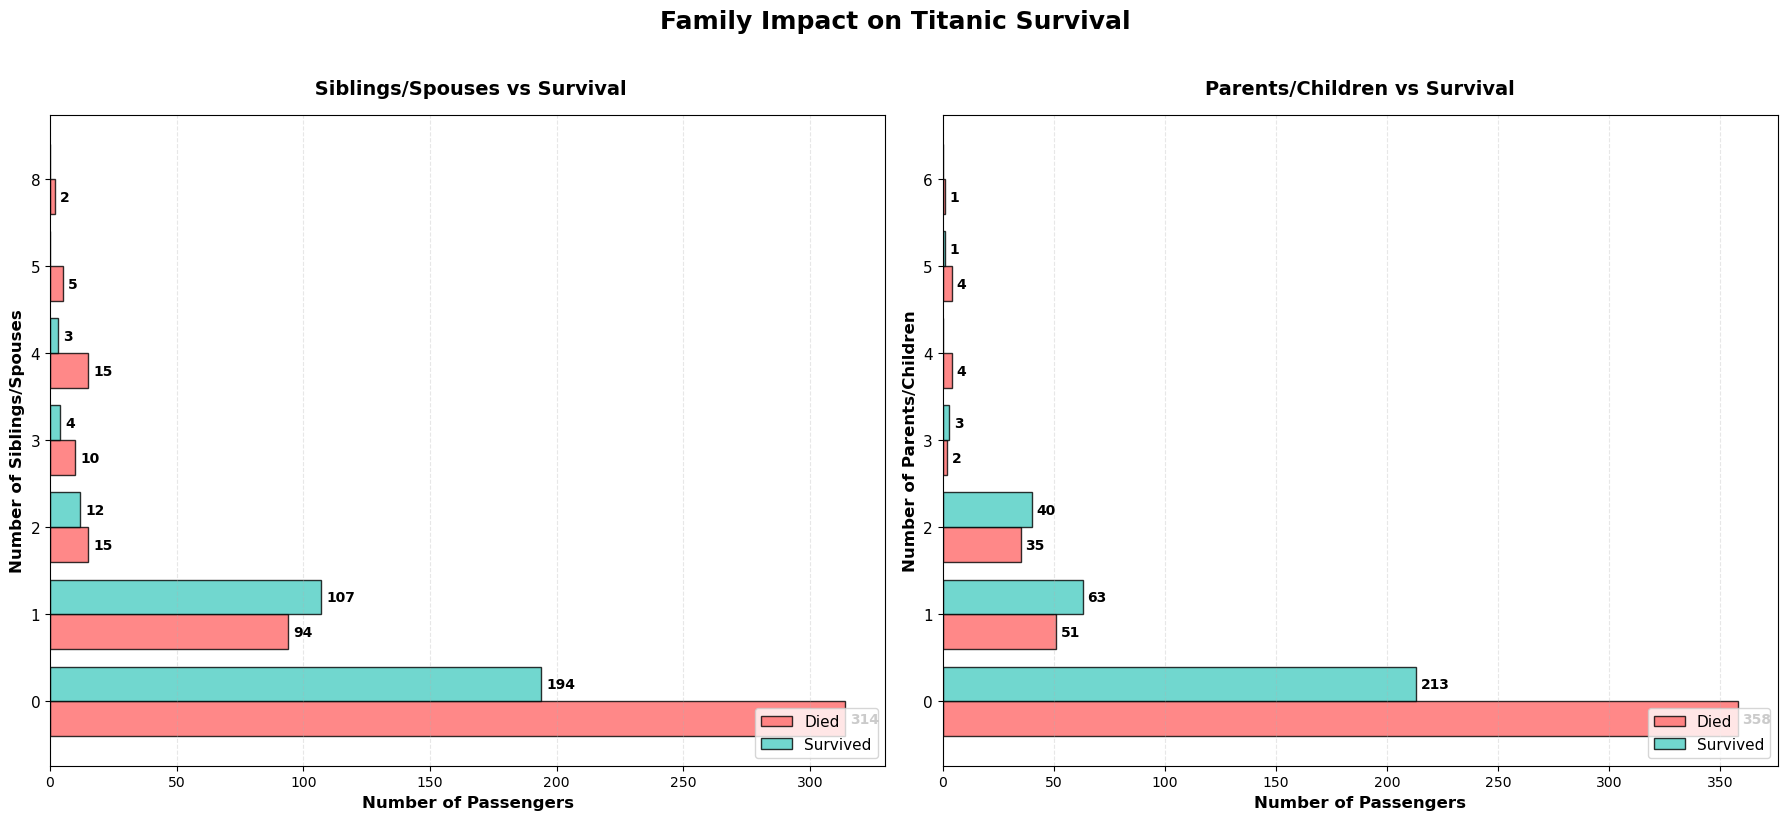

In [79]:
# Horizontal bar chart

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: survival by number of siblings/spouses
sibsp_survival = pd.crosstab(df['sibsp'], df['survived'])
sibsp_survival.columns = ['Died', 'Survived']


y_pos_sibsp = np.arange(len(sibsp_survival.index))

ax1.barh(y_pos_sibsp - 0.2, sibsp_survival['Died'], height=0.4, 
         label='Died', color='#ff6b6b', edgecolor='black', alpha=0.8)
ax1.barh(y_pos_sibsp + 0.2, sibsp_survival['Survived'], height=0.4, 
         label='Survived', color='#4ecdc4', edgecolor='black', alpha=0.8)


ax1.set_yticks(y_pos_sibsp)
ax1.set_yticklabels(sibsp_survival.index, fontsize=11)
ax1.set_xlabel('Number of Passengers', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Siblings/Spouses', fontsize=12, fontweight='bold')
ax1.set_title(' Siblings/Spouses vs Survival', fontsize=14, fontweight='bold', pad=15)
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(True, alpha=0.3, axis='x', linestyle='--')

# show the numbers beside the bars
for i, (died, survived) in enumerate(zip(sibsp_survival['Died'], sibsp_survival['Survived'])):
    if died > 0:
        ax1.text(died + 2, i - 0.2, str(died), va='center', fontsize=10, fontweight='bold')
    if survived > 0:
        ax1.text(survived + 2, i + 0.2, str(survived), va='center', fontsize=10, fontweight='bold')



# Subplot 2: survival by number of parents/children
parch_survival = pd.crosstab(df['parch'], df['survived'])
parch_survival.columns = ['Died', 'Survived']

y_pos_parch = np.arange(len(parch_survival.index))

ax2.barh(y_pos_parch - 0.2, parch_survival['Died'], height=0.4, 
         label='Died', color='#ff6b6b', edgecolor='black', alpha=0.8)
ax2.barh(y_pos_parch + 0.2, parch_survival['Survived'], height=0.4, 
         label='Survived', color='#4ecdc4', edgecolor='black', alpha=0.8)


ax2.set_yticks(y_pos_parch)
ax2.set_yticklabels(parch_survival.index, fontsize=11)
ax2.set_xlabel('Number of Passengers', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Parents/Children', fontsize=12, fontweight='bold')
ax2.set_title('Parents/Children vs Survival', fontsize=14, fontweight='bold', pad=15)
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(True, alpha=0.3, axis='x', linestyle='--')

# show the numbers beside the bars
for i, (died, survived) in enumerate(zip(parch_survival['Died'], parch_survival['Survived'])):
    if died > 0:
        ax2.text(died + 2, i - 0.2, str(died), va='center', fontsize=10, fontweight='bold')
    if survived > 0:
        ax2.text(survived + 2, i + 0.2, str(survived), va='center', fontsize=10, fontweight='bold')


plt.suptitle('Family Impact on Titanic Survival', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

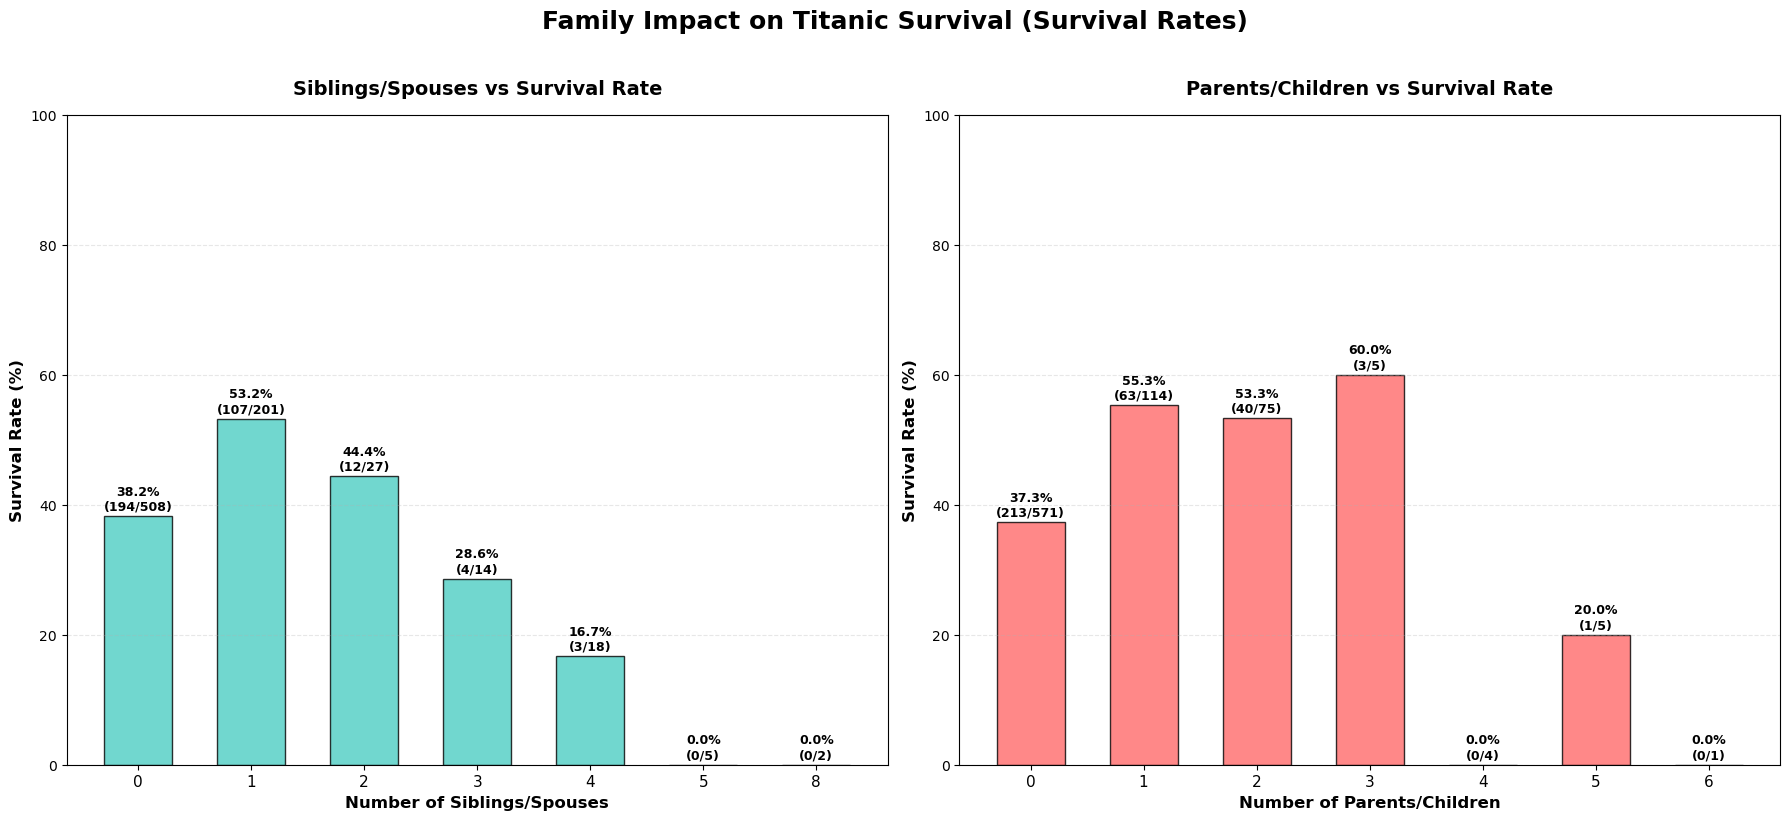

In [80]:
# Bar chart 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: survival by percentage of siblings/spouses 
sibsp_survival = pd.crosstab(df['sibsp'], df['survived'])
sibsp_survival.columns = ['Died', 'Survived']

# calculate survival rate percentage
sibsp_survival['Survival_Rate'] = (sibsp_survival['Survived'] / (sibsp_survival['Survived'] + sibsp_survival['Died']) * 100).round(1)
sibsp_survival['Total'] = sibsp_survival['Survived'] + sibsp_survival['Died']

x_pos_sibsp = np.arange(len(sibsp_survival.index))

# create percentage bars
bars1 = ax1.bar(x_pos_sibsp, sibsp_survival['Survival_Rate'], width=0.6, 
                label='Survival Rate', color='#4ecdc4', edgecolor='black', alpha=0.8)

ax1.set_xticks(x_pos_sibsp)
ax1.set_xticklabels(sibsp_survival.index, fontsize=11)
ax1.set_xlabel('Number of Siblings/Spouses', fontsize=12, fontweight='bold')
ax1.set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Siblings/Spouses vs Survival Rate', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# add percentage and count labels on top of bars
for i, (rate, total, survived) in enumerate(zip(sibsp_survival['Survival_Rate'], 
                                                  sibsp_survival['Total'],
                                                  sibsp_survival['Survived'])):
    ax1.text(i, rate + 1, f'{rate}%\n({survived}/{total})', 
             ha='center', fontsize=9, fontweight='bold')
    

# Subplot 2: survival by percentage of parents/children 
parch_survival = pd.crosstab(df['parch'], df['survived'])
parch_survival.columns = ['Died', 'Survived']

# calculate survival rate percentage
parch_survival['Survival_Rate'] = (parch_survival['Survived'] / (parch_survival['Survived'] + parch_survival['Died']) * 100).round(1)
parch_survival['Total'] = parch_survival['Survived'] + parch_survival['Died']

x_pos_parch = np.arange(len(parch_survival.index))

# create percentage bars
bars2 = ax2.bar(x_pos_parch, parch_survival['Survival_Rate'], width=0.6, 
                label='Survival Rate', color='#ff6b6b', edgecolor='black', alpha=0.8)

ax2.set_xticks(x_pos_parch)
ax2.set_xticklabels(parch_survival.index, fontsize=11)
ax2.set_xlabel('Number of Parents/Children', fontsize=12, fontweight='bold')
ax2.set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Parents/Children vs Survival Rate', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# add percentage and count labels on top of bars
for i, (rate, total, survived) in enumerate(zip(parch_survival['Survival_Rate'], 
                                                  parch_survival['Total'],
                                                  parch_survival['Survived'])):
    ax2.text(i, rate + 1, f'{rate}%\n({survived}/{total})', 
             ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Family Impact on Titanic Survival (Survival Rates)', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\melin\AppData\Local\Temp\ipykernel_21072\3215124048.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = axes[0].scatter(df['age_years'], df['fare_dollars'], alpha=0.6, s=50, cmap='coolwarm')
C:\Users\melin\AppData\Local\Temp\ipykernel_21072\3215124048.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  bubble = axes[1].scatter(class_data['age_years'], class_data['survived'], s=normalized_size,


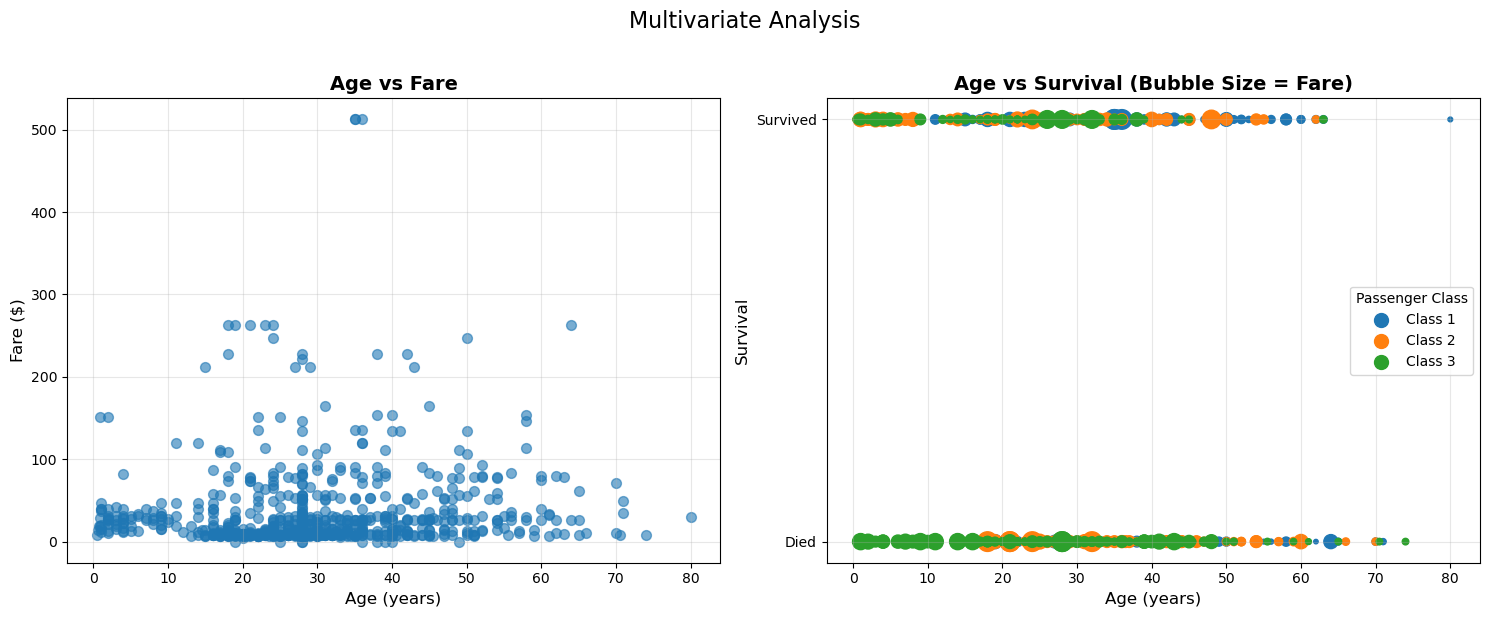

In [82]:
# Scatter plot

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# age vs Fare by Survival
scatter = axes[0].scatter(df['age_years'], df['fare_dollars'], alpha=0.6, s=50, cmap='coolwarm')
axes[0].set_title('Age vs Fare', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Fare ($)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Bubble chart
for pclass in [1, 2, 3]:
    class_data = df[df['pclass'] == pclass]
    normalized_size = (class_data['fare_dollars'] / class_data['fare_dollars'].max()) * 200
    bubble = axes[1].scatter(class_data['age_years'], class_data['survived'], s=normalized_size, 
                            label=f'Class {pclass}', cmap='viridis')
    
axes[1].set_title('Age vs Survival (Bubble Size = Fare)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age (years)', fontsize=12)
axes[1].set_ylabel('Survival', fontsize=12)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Died', 'Survived'])
axes[1].legend(title='Passenger Class')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Multivariate Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [84]:
# interactive plot

fig = go.Figure()

# add violin plot (shows distribution shape)
fig.add_trace(go.Violin(
    x=df['pclass'], 
    y=df['age_years'],
    box_visible=True,            # Shows box plot inside violin
    line_color='black',          # Border color
    meanline_visible=True,       # Shows mean as a line
    fillcolor='lightseagreen',   # Fill color
    opacity=0.7,                 # Transparency
    name='Age Distribution',
    points='all',                # Show all data points
    jitter=0.3,                  # Spread out points
    pointpos=-1.5                # Position of points
))

# update layout with titles and formatting
fig.update_layout(
    title={
        'text': 'Interactive Age Distribution by Passenger Class',
        'x': 0.5,                # Center the title
        'xanchor': 'center',
        'font': {'size': 18, 'family': 'Arial', 'weight': 'bold'}
    },
    xaxis_title={
        'text': 'Passenger Class',
        'font': {'size': 14, 'weight': 'bold'}
    },
    yaxis_title={
        'text': 'Age (years)',
        'font': {'size': 14, 'weight': 'bold'}
    },
    height=600,
    width=800,
    template='plotly_white',
    showlegend=True,
    legend={
        'title': {'text': 'Class Distribution', 'font': {'size': 12}},
        'x': 0.95,
        'y': 0.95,
        'xanchor': 'right',
        'yanchor': 'top'
    }
)

# add horizontal line for overall average age
overall_mean_age = df['age_years'].mean()
fig.add_hline(
    y=overall_mean_age, 
    line_dash="dash", 
    line_color="red",
    opacity=0.5,
    annotation_text=f"Overall Mean Age: {overall_mean_age:.1f} years",
    annotation_position="top right"
)

# customize y-axis range
fig.update_yaxes(range=[0, 85])

# display the figure
fig.show()



In [43]:
# 3D visualization showing class, age, and survival

fig1 = px.scatter_3d(
    df,
    x='age_years',
    y='fare_dollars',
    z='pclass',
    color='survived',
    symbol='sex',
    size='family_size',
    size_max=15,
    opacity=0.8,
    hover_data=['pclass', 'age_group', 'fare_tier', 'sibsp', 'parch'],
    title=' RMS Titanic: The Survival Landscape 3D View of Age, Wealth, and Class Impact',
    labels={
        'age_years': 'Age (years)',
        'fare_dollars': 'Ticket Fare (£)',
        'pclass': 'Passenger Class',
        'survived': 'Outcome',
        'sex': 'Gender',
        'family_size': 'Family Size'
    },
    color_continuous_scale=['#e74c3c', '#2ecc71']  # Red=Died, Green=Survived
)

# Add custom styling 
fig1.update_layout(
    showlegend=False, 
    title_font_size=20,
    title_font_family="Georgia",
    scene=dict(
        xaxis_title='<b>Age (years)</b>',
        yaxis_title='<b>Fare (£)</b>',
        zaxis_title='<b>Class (1st=Rich, 3rd=Poor)</b>',
        zaxis=dict(autorange='reversed'),
        camera_eye=dict(x=1.5, y=1.5, z=1.2),
        bgcolor='rgba(200, 220, 240, 0.1)'
    ),
    hovermode='closest'
)

# Add annotation explaining the chart
fig1.add_annotation(
    xref="paper", yref="paper",
    x=0.02, y=0.98,
    text="<b> Insight:</b> 🟢 Green = Survived (1) &nbsp;&nbsp;|&nbsp;&nbsp; 🔴 Red = Died (0)<br>"
         "Female (square) &nbsp;&nbsp;|&nbsp;&nbsp;  Male (circle)<br>"
         "Shape size = Family size",
    showarrow=False,
    font=dict(size=10),
    bgcolor="rgba(255, 255, 255, 0.85)",
    bordercolor="black",
    borderwidth=1,
    align="left"
)

fig1.show()

For data visualisation part we tried to plot different kinds of plots such as pie chart, bar chart, stacked bar chart, box plot ... which were appropriate based on the data we tried to analyse. 

## 3. Feature Engineering

In [10]:
# create new features

# family size = siblings/spouses + parents/children + the person 
df['family_size'] = df['sibsp'] + df['parch'] + 1

# fare per person = fare / family size
df['fare_per_person'] = df['fare_dollars'] / df['family_size']


In [120]:
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,age_years,fare_dollars,family_size,fare_per_person
0,0,3,1,-0.551060,1,0,-0.527515,2,0,22.0,7.2500,2,3.62500
1,1,1,0,0.611945,1,0,0.695086,0,0,38.0,71.2833,2,35.64165
2,1,3,0,-0.260308,0,0,-0.514627,2,1,26.0,7.9250,1,7.92500
3,1,1,0,0.393881,1,0,0.347909,2,0,35.0,53.1000,2,26.55000
4,0,3,1,0.393881,0,0,-0.512240,2,1,35.0,8.0500,1,8.05000


In [11]:
# binning

# age binning 
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['age_years'], bins=age_bins, labels=age_labels)
print("age_group: 5 categories (Child, Teen, Young Adult, Adult, Senior)")

# fare binning 
fare_bins = [0, 10, 20, 40, 100, 600]
fare_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df['fare_tier'] = pd.cut(df['fare_dollars'], bins=fare_bins, labels=fare_labels)
print("fare_tier: 5 economic tiers based on ticket price")


age_group: 5 categories (Child, Teen, Young Adult, Adult, Senior)
fare_tier: 5 economic tiers based on ticket price


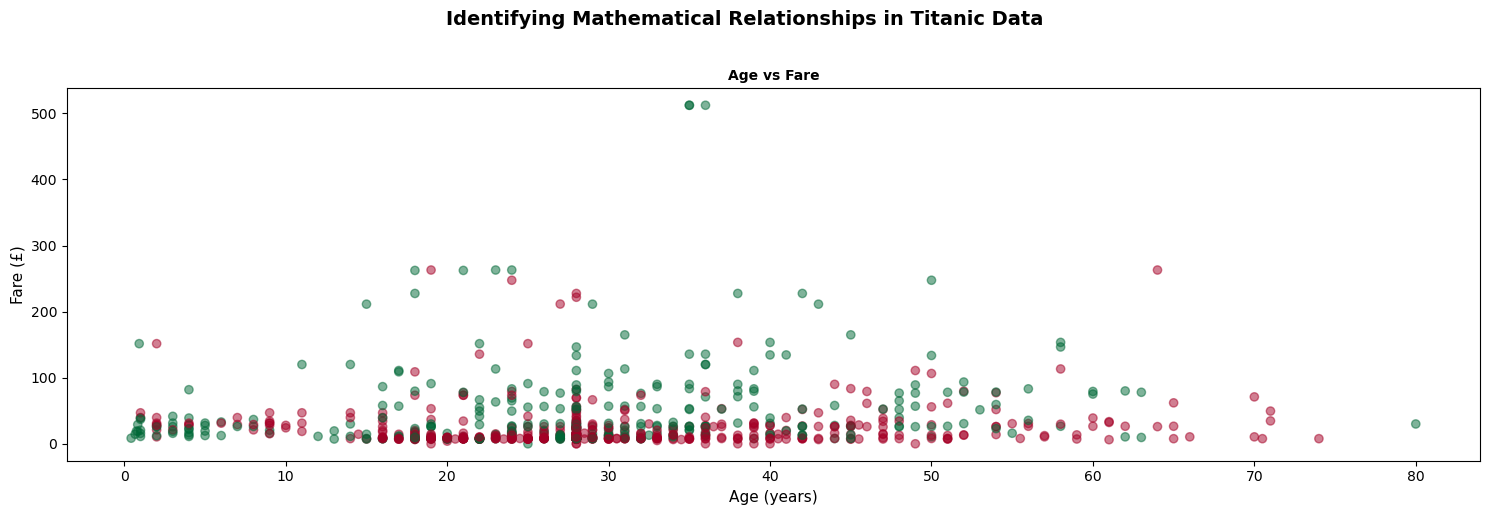

In [12]:
# mathematical function

# create scatter plot to see if there is any mathematical relations
fig, axes = plt.subplots(figsize=(15, 5))

# age vs fare 
axes.scatter(df['age_years'], df['fare_dollars'], alpha=0.5, c=df['survived'], cmap='RdYlGn')
axes.set_xlabel('Age (years)', fontsize=11)
axes.set_ylabel('Fare (£)', fontsize=11)
axes.set_title('Age vs Fare', fontsize=10, fontweight='bold')


plt.suptitle('Identifying Mathematical Relationships in Titanic Data', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

>It seems there is no mathematical relations.

So we will look for more complex characteristics that can have relations. We take the steps below to find some mathematical relations between columns.


1️ Class Impact:
   1st Class survival: 63.3% → Risk: 36.7%
   2nd Class survival: 50.6% → Risk: 49.4%
   3rd Class survival: 25.9% → Risk: 74.1%

2️ Age >50 Impact:
   Age ≤50 survival: 41.9% → Risk: 58.1%
   Age >50 survival: 34.9% → Risk: 65.1%
   Risk increase: 0.1%

3️ Gender Impact:
   Female survival: 74.0% → Risk: 26.0%
   Male survival: 21.5% → Risk: 78.5%
   Risk difference: 0.5%

4️ Large Family Impact:
   Small family survival: 42.7% → Risk: 57.3%
   Large family survival: 16.7% → Risk: 83.3%
   Risk increase: 0.3%


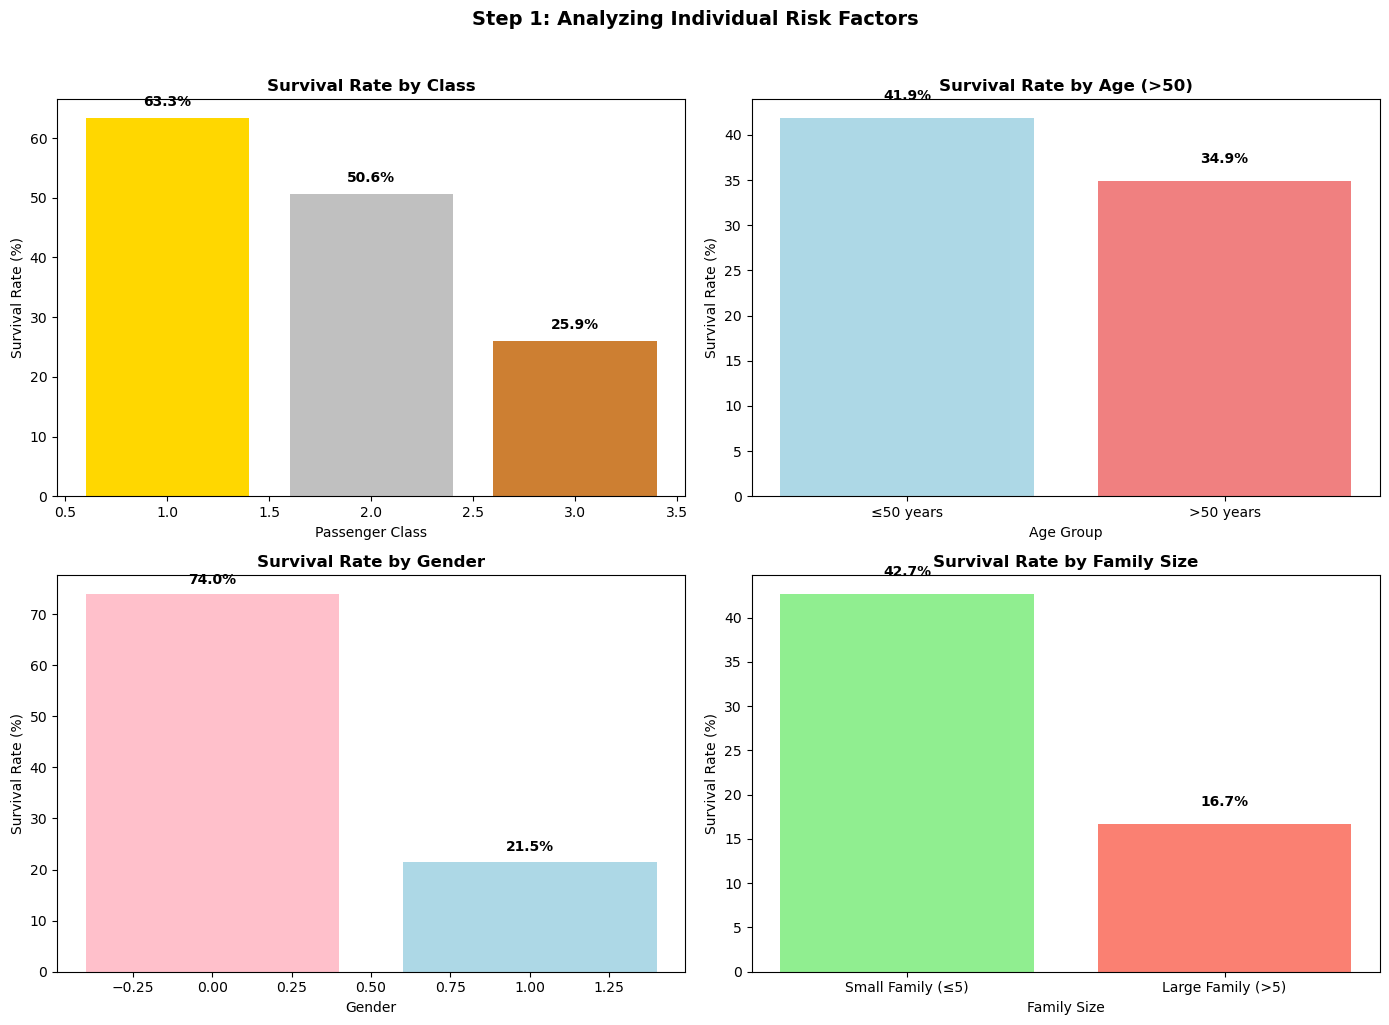

In [13]:
# Step 1: We plot some useful plots & calculate risk factor

fig, axes = plt.subplots(2, 2, figsize=(14, 10))  

# Factor 1: Passenger Class 
class_survival = df.groupby('pclass')['survived'].mean()
class_risk = 1 - class_survival
axes[0, 0].bar(class_survival.index, class_survival.values * 100, color=['gold', 'silver', '#cd7f32'])
axes[0, 0].set_title('Survival Rate by Class', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Passenger Class', fontsize=10)
axes[0, 0].set_ylabel('Survival Rate (%)', fontsize=10)
for i, (cls, rate) in enumerate(class_survival.items()):
    axes[0, 0].text(cls, rate * 100 + 2, f'{rate*100:.1f}%', ha='center', fontweight='bold')

print("\n1️ Class Impact:")
print(f"   1st Class survival: {class_survival[1]*100:.1f}% → Risk: {(1-class_survival[1])*100:.1f}%")
print(f"   2nd Class survival: {class_survival[2]*100:.1f}% → Risk: {(1-class_survival[2])*100:.1f}%")
print(f"   3rd Class survival: {class_survival[3]*100:.1f}% → Risk: {(1-class_survival[3])*100:.1f}%")

# Factor 2: Age (>50 vs ≤50)
df['age_old'] = (df['age_years'] > 50).astype(int)
age_risk = df.groupby('age_old')['survived'].mean()
axes[0, 1].bar(['≤50 years', '>50 years'], age_risk.values * 100, color=['lightblue', 'lightcoral'])
axes[0, 1].set_title('Survival Rate by Age (>50)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age Group', fontsize=10)
axes[0, 1].set_ylabel('Survival Rate (%)', fontsize=10)
for i, rate in enumerate(age_risk.values):
    axes[0, 1].text(i, rate * 100 + 2, f'{rate*100:.1f}%', ha='center', fontweight='bold')

print(f"\n2️ Age >50 Impact:")
print(f"   Age ≤50 survival: {age_risk[0]*100:.1f}% → Risk: {(1-age_risk[0])*100:.1f}%")
print(f"   Age >50 survival: {age_risk[1]*100:.1f}% → Risk: {(1-age_risk[1])*100:.1f}%")
print(f"   Risk increase: {(1-age_risk[1]) - (1-age_risk[0]):.1f}%")

# Factor 3: Gender
gender_survival = df.groupby('sex')['survived'].mean()
axes[1, 0].bar(gender_survival.index, gender_survival.values * 100, color=['pink', 'lightblue'])
axes[1, 0].set_title('Survival Rate by Gender', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Gender', fontsize=10)
axes[1, 0].set_ylabel('Survival Rate (%)', fontsize=10)
for i, rate in enumerate(gender_survival.values):
    axes[1, 0].text(i, rate * 100 + 2, f'{rate*100:.1f}%', ha='center', fontweight='bold')

print(f"\n3️ Gender Impact:")
print(f"   Female survival: {gender_survival[0]*100:.1f}% → Risk: {(1-gender_survival[0])*100:.1f}%")
print(f"   Male survival: {gender_survival[1]*100:.1f}% → Risk: {(1-gender_survival[1])*100:.1f}%")
print(f"   Risk difference: {(1-gender_survival[1]) - (1-gender_survival[0]):.1f}%")


# Factor 4: Large Family (>5 members)
df['large_family'] = (df['family_size'] > 5).astype(int)
family_risk = df.groupby('large_family')['survived'].mean()
axes[1, 1].bar(['Small Family (≤5)', 'Large Family (>5)'], family_risk.values * 100, color=['lightgreen', 'salmon'])
axes[1, 1].set_title('Survival Rate by Family Size', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Family Size', fontsize=10)
axes[1, 1].set_ylabel('Survival Rate (%)', fontsize=10)
for i, rate in enumerate(family_risk.values):
    axes[1, 1].text(i, rate * 100 + 2, f'{rate*100:.1f}%', ha='center', fontweight='bold')

print(f"\n4️ Large Family Impact:")
print(f"   Small family survival: {family_risk[0]*100:.1f}% → Risk: {(1-family_risk[0])*100:.1f}%")
print(f"   Large family survival: {family_risk[1]*100:.1f}% → Risk: {(1-family_risk[1])*100:.1f}%")
print(f"   Risk increase: {(1-family_risk[1]) - (1-family_risk[0]):.1f}%")

plt.suptitle('Step 1: Analyzing Individual Risk Factors', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Step 2: Calculate risk weights

# Calculate the risk difference for each factor
risk_data = {}

# Class risk (using 3rd class as baseline)
class_risk_values = {1: 1 - class_survival[1], 2: 1 - class_survival[2], 3: 1 - class_survival[3]}
max_class_risk = max(class_risk_values.values())
min_class_risk = min(class_risk_values.values())
class_weight = max_class_risk - min_class_risk  # Difference between worst and best class

# Age risk
age_risk_values = {0: 1 - age_risk[0], 1: 1 - age_risk[1]}
age_weight = age_risk_values[1] - age_risk_values[0]

# Gender risk
gender_risk_values = {'female': 1 - gender_survival[0], 'male': 1 - gender_survival[1]}
gender_weight = gender_risk_values['male'] - gender_risk_values['female']

# Family size risk
family_risk_values = {0: 1 - family_risk[0], 1: 1 - family_risk[1]}
family_weight = family_risk_values[1] - family_risk_values[0]

# Display calculated weights
print("\nCalculated Risk Differences (Weights):")
print(f"  Class impact: {class_weight:.3f} (range from {min_class_risk:.3f} to {max_class_risk:.3f})")
print(f"  Age >50 impact: {age_weight:.3f}")
print(f"  Gender impact: {gender_weight:.3f}")
print(f"  Large family impact: {family_weight:.3f}")

# Normalize weights to sum to 1
total_weight = class_weight + age_weight + gender_weight + family_weight
normalized_weights = {
    'class': class_weight / total_weight,
    'age': age_weight / total_weight,
    'gender': gender_weight / total_weight,
    'family': family_weight / total_weight
}

print(f"\nNormalized Weights (sum to 1):")
print(f"  Class: {normalized_weights['class']:.3f}")
print(f"  Age >50: {normalized_weights['age']:.3f}")
print(f"  Gender: {normalized_weights['gender']:.3f}")
print(f"  Family: {normalized_weights['family']:.3f}")


Calculated Risk Differences (Weights):
  Class impact: 0.374 (range from 0.367 to 0.741)
  Age >50 impact: 0.069
  Gender impact: 0.524
  Large family impact: 0.260

Normalized Weights (sum to 1):
  Class: 0.305
  Age >50: 0.056
  Gender: 0.427
  Family: 0.212



Risk Score Correlation with Actual Death: 0.556

Actual Death Rate by Risk Score Group:
  Very Low  : 5.5% death rate
  Low       : 55.5% death rate
  Medium    : 81.9% death rate
  High      : 82.9% death rate
  Very High : 95.2% death rate


C:\Users\melin\AppData\Local\Temp\ipykernel_22384\341423306.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  actual_risk_by_group = df.groupby(risk_groups)['actual_risk'].mean()


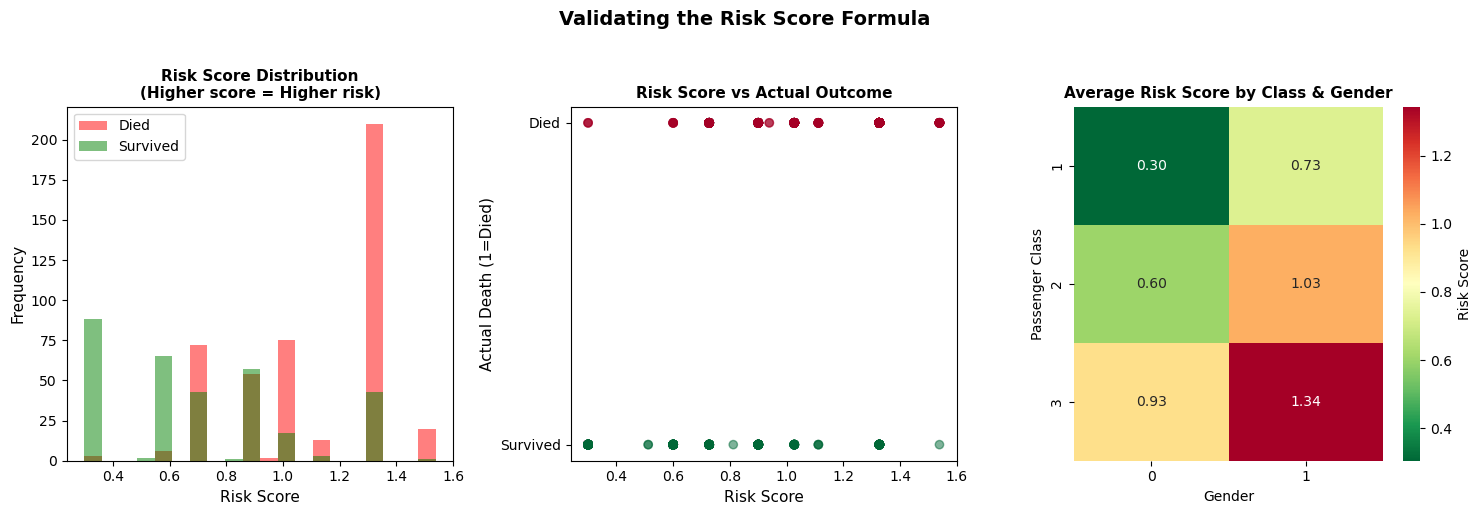

In [15]:
# Step 3: Formulating the risk factor

# Create the risk score using the formula
df['risk_score'] = (
    (df['pclass'] * 0.3) + 
    ((df['age'] > 50).astype(int) * 0.056) + 
    ((df['sex']).astype(int) * 0.427) +
    ((df['family_size'] > 5).astype(int) * 0.212)
)

df['actual_risk'] = 1 - df['survived']

# Validate
print(f"\nRisk Score Correlation with Actual Death: {df['risk_score'].corr(df['actual_risk']):.3f}")
# Group by risk score to see if it predicts well
risk_groups = pd.qcut(df['risk_score'], 5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
actual_risk_by_group = df.groupby(risk_groups)['actual_risk'].mean()

print("\nActual Death Rate by Risk Score Group:")
for group, rate in actual_risk_by_group.items():
    print(f"  {group:10s}: {rate*100:.1f}% death rate")

# Visualize validation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Risk score distribution by survival
for survival in [0, 1]:
    subset = df[df['survived'] == survival]
    axes[0].hist(subset['risk_score'], bins=20, alpha=0.5, 
                 label=f'{"Died" if survival==0 else "Survived"}', 
                 color=['red', 'green'][survival])
axes[0].set_xlabel('Risk Score', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Risk Score Distribution\n(Higher score = Higher risk)', fontsize=11, fontweight='bold')
axes[0].legend()

# Plot 2: Risk score vs actual survival
axes[1].scatter(df['risk_score'], df['actual_risk'], alpha=0.5, c=df['survived'], cmap='RdYlGn')
axes[1].set_xlabel('Risk Score', fontsize=11)
axes[1].set_ylabel('Actual Death (1=Died)', fontsize=11)
axes[1].set_title('Risk Score vs Actual Outcome', fontsize=11, fontweight='bold')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Survived', 'Died'])

# Plot 3: Risk score heatmap by class and gender
risk_pivot = df.pivot_table(values='risk_score', index='pclass', columns='sex', aggfunc='mean')
sns.heatmap(risk_pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[2], cbar_kws={'label': 'Risk Score'})
axes[2].set_title('Average Risk Score by Class & Gender', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Gender', fontsize=10)
axes[2].set_ylabel('Passenger Class', fontsize=10)

plt.suptitle('Validating the Risk Score Formula', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [145]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,age_years,fare_dollars,family_size,fare_per_person,age_group,fare_tier,age_old,large_family,risk_score,actual_risk
0,0,3,1,-0.551060,1,0,-0.527515,2,0,22.0,7.2500,2,3.62500,Young Adult,Very Low,0,0,1.327,1
1,1,1,0,0.611945,1,0,0.695086,0,0,38.0,71.2833,2,35.64165,Adult,High,0,0,0.300,0
2,1,3,0,-0.260308,0,0,-0.514627,2,1,26.0,7.9250,1,7.92500,Young Adult,Very Low,0,0,0.900,0
3,1,1,0,0.393881,1,0,0.347909,2,0,35.0,53.1000,2,26.55000,Young Adult,High,0,0,0.300,0
4,0,3,1,0.393881,0,0,-0.512240,2,1,35.0,8.0500,1,8.05000,Young Adult,Very Low,0,0,1.327,1


In [16]:
# aggregation

age_survival_rate = df.groupby(pd.cut(df['age'], bins=10))['survived'].transform('mean')
df['age_survival_rate'] = age_survival_rate
print("age_survival_rate: Average survival for similar age groups")

age_survival_rate: Average survival for similar age groups


C:\Users\melin\AppData\Local\Temp\ipykernel_22384\3100861346.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival_rate = df.groupby(pd.cut(df['age'], bins=10))['survived'].transform('mean')


Features for selection: 14 numeric features
Target: Survival (775 samples)


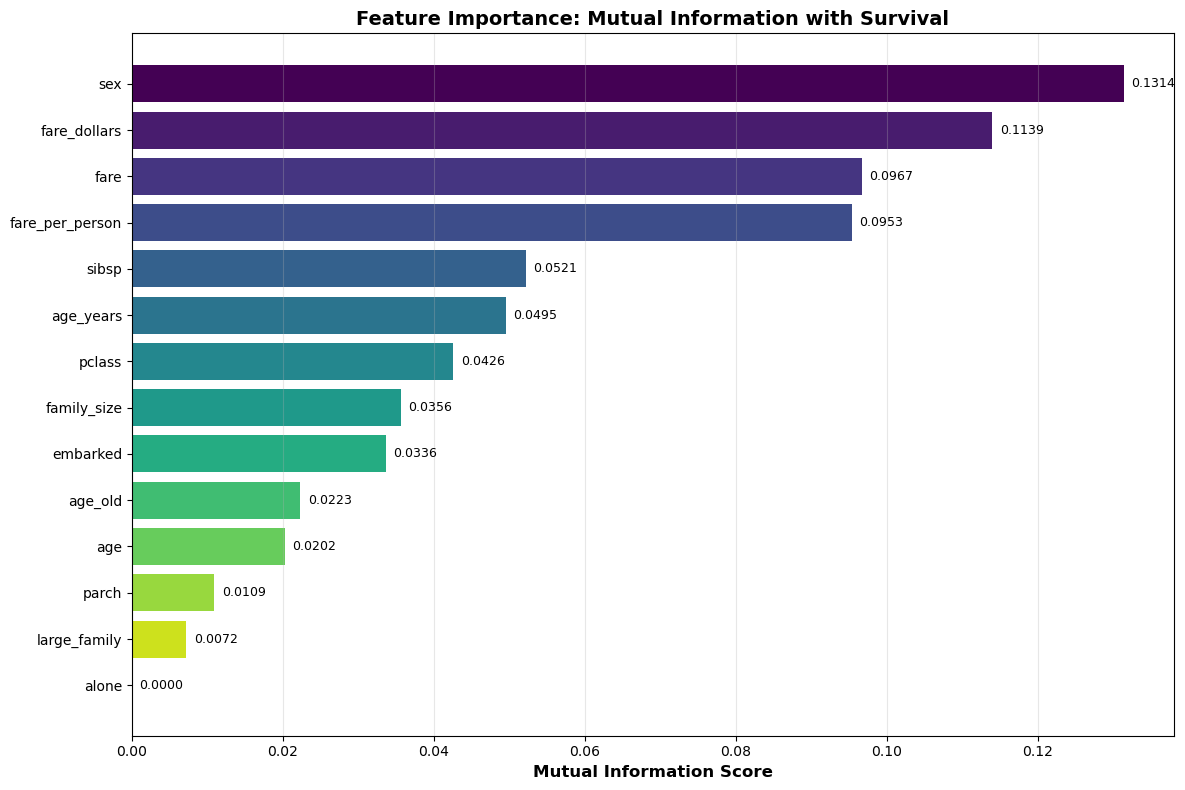


 Selected TOP 10 features:
 1. sex                            (MI: 0.1314)
 2. fare_dollars                   (MI: 0.1139)
 3. fare                           (MI: 0.0967)
 4. fare_per_person                (MI: 0.0953)
 5. sibsp                          (MI: 0.0521)
 6. age_years                      (MI: 0.0495)
 7. pclass                         (MI: 0.0426)
 8. family_size                    (MI: 0.0356)
 9. embarked                       (MI: 0.0336)
10. age_old                        (MI: 0.0223)


In [17]:
# feature selection

columns_to_drop = ['risk_score', 'actual_risk', 'age_survival_rate']

df_fe = df.drop(columns=columns_to_drop)

# Prepare features and target
X = df_fe.drop('survived', axis=1)
y = df_fe['survived']

# Remove any remaining non-numeric columns (just in case)
X = X.select_dtypes(include=[np.number])

print(f"Features for selection: {X.shape[1]} numeric features")
print(f"Target: Survival ({len(y)} samples)")

# Calculate Mutual Information scores
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)


# Visualize MI scores
fig, ax = plt.subplots(figsize=(12, 8))
top_features = mi_scores_series.head(20)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = ax.barh(range(len(top_features)), top_features.values, color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index)
ax.set_xlabel('Mutual Information Score', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance: Mutual Information with Survival', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (feature, score) in enumerate(top_features.items()):
    ax.text(score + 0.001, i, f'{score:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Select top K features 
k_best = 10
selector = SelectKBest(mutual_info_classif, k=k_best)
X_selected = selector.fit_transform(X, y)

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X.columns)

# Get the top k features based on MI scores
selected_features = mi_scores_series.nlargest(k_best).index

print(f"\n Selected TOP {k_best} features:")
print("="*60)
for i, feature in enumerate(selected_features, 1):
    score = mi_scores_series[feature]
    print(f"{i:2d}. {feature:30s} (MI: {score:.4f})")


 PCA Analysis Results:
   • Original features: 10
   • PCA components needed for 95% variance: 7
   • Total explained variance with all components: 100.00%


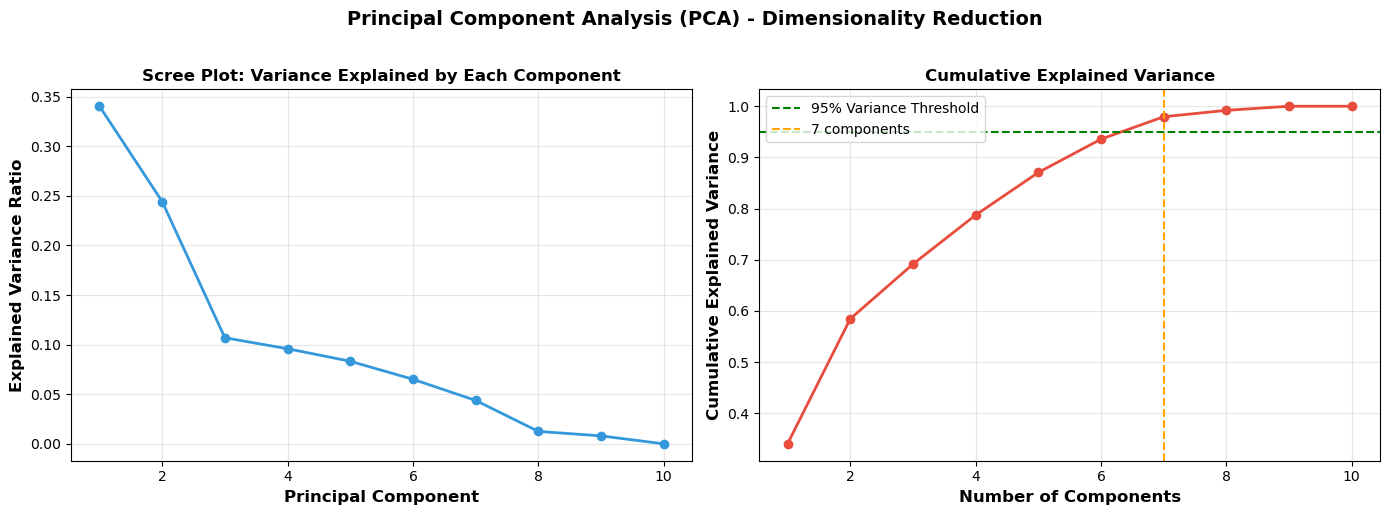


 PCA Results:
   • Reduced from 10 features to 7 components
   • Preserved 95% of the original information
   • New shape: (775, 7)

 Top features contributing to first 3 PCA components:

PC1 - Top 5 features:
   • pclass: 0.524
   • fare: 0.524
   • embarked: 0.461
   • sex: 0.369
   • fare_per_person: 0.184

PC2 - Top 5 features:
   • family_size: 0.596
   • age_old: 0.488
   • sibsp: 0.453
   • age_years: 0.318
   • embarked: 0.180

PC3 - Top 5 features:
   • fare_dollars: 0.652
   • fare_per_person: 0.518
   • age_old: 0.383
   • age_years: 0.232
   • sibsp: 0.226


In [18]:
# PCA

# Standardize features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\n PCA Analysis Results:")
print(f"   • Original features: {X_selected.shape[1]}")
print(f"   • PCA components needed for 95% variance: {n_components_95}")
print(f"   • Total explained variance with all components: {cumulative_variance[-1]:.2%}")

# Visualize explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
components = range(1, len(explained_variance_ratio) + 1)
ax1.plot(components, explained_variance_ratio, 'o-', linewidth=2, markersize=6, color='#3498db')
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax1.set_title('Scree Plot: Variance Explained by Each Component', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Cumulative variance plot
ax2.plot(components, cumulative_variance, 'o-', linewidth=2, markersize=6, color='#e74c3c')
ax2.axhline(y=0.95, color='green', linestyle='--', label='95% Variance Threshold')
ax2.axvline(x=n_components_95, color='orange', linestyle='--', label=f'{n_components_95} components')
ax2.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Principal Component Analysis (PCA) - Dimensionality Reduction', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Apply PCA with optimal components
pca_optimal = PCA(n_components=n_components_95)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

print(f"\n PCA Results:")
print(f"   • Reduced from {X_selected.shape[1]} features to {n_components_95} components")
print(f"   • Preserved 95% of the original information")
print(f"   • New shape: {X_pca_optimal.shape}")

# Analyze PCA components
print("\n Top features contributing to first 3 PCA components:")
loadings = pd.DataFrame(
    pca_optimal.components_[:3].T,
    columns=[f'PC{i+1}' for i in range(3)],
    index=selected_features
)

for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n{pc} - Top 5 features:")
    top_features_pc = loadings[pc].abs().sort_values(ascending=False).head(5)
    for feature, loading in top_features_pc.items():
        print(f"   • {feature}: {loading:.3f}")

**Question**: When is feature engineering a nice-to-have option, and when is it a must-have?

Engineer features when the raw data cannot be directly used by your model. Otherwise, start simple and add complexity only when needed.

In this section, we created some new features by combinig columns, for example created column family size based on sibsp and parch columns. Then binned two of the columns, 'age' and 'fare' because they were the only numeric columns that needed binning. After that we went through creating some more complex features as explained step by step and created a new column named 'risk_score'. Then we used aggregation and created a new column named 'age_survival_rate' which compares each individual's age with the mean age that has survived. Then I used mutual information and found top features that have correlation with the 'survived' column. In the end we used PCA for dimensionality reduction.

## 4. Save data

In [160]:

# Create final dataset with PCA features
final_df = pd.DataFrame(X_pca_optimal, columns=[f'PC_{i+1}' for i in range(n_components_95)])
final_df['survived'] = y.values

# Save to CSV
final_df.to_csv('titanic_engineered_pca_features.csv', index=False)
print("Saved: 'titanic_engineered_pca_features.csv'")

# Also save the full engineered dataset
df.to_csv('titanic_full_engineered.csv', index=False)
print("Saved: 'titanic_full_engineered.csv'")

Saved: 'titanic_engineered_pca_features.csv'
Saved: 'titanic_full_engineered.csv'


In [162]:
# Final report

print("\n" + "="*80)
print("FINAL REPORT: FEATURE ENGINEERING & SELECTION")
print("="*80)

print("1. BEST NEW FEATURES:")
for i, feature in enumerate(selected_features[:5], 1):
    score = mi_scores_series[feature]
    print(f"   {i}. {feature}: {score:.4f} MI score")

print(f"\n2. PCA EFFICIENCY:")
print(f"   • Original features: {X.shape[1]}")
print(f"   • After selection: {len(selected_features)}")
print(f"   • After PCA: {n_components_95}")
print(f"   • Reduction: {100 - (n_components_95/len(selected_features)*100):.1f}%")

print("\n3. RECOMMENDED FINAL FEATURES:")
print(f"   For model training, use the PCA components (PC_1 to PC_{n_components_95})")
print("   These preserve 95% of information with reduced dimensions")



FINAL REPORT: FEATURE ENGINEERING & SELECTION
1. BEST NEW FEATURES:
   1. sex: 0.1314 MI score
   2. fare_dollars: 0.1139 MI score
   3. fare: 0.0967 MI score
   4. fare_per_person: 0.0953 MI score
   5. sibsp: 0.0521 MI score

2. PCA EFFICIENCY:
   • Original features: 14
   • After selection: 10
   • After PCA: 7
   • Reduction: 30.0%

3. RECOMMENDED FINAL FEATURES:
   For model training, use the PCA components (PC_1 to PC_7)
   These preserve 95% of information with reduced dimensions


In the last part we saved the .csv file which contains the cleaned data, and also gave a summary about the data for further usage in ML projects or any other projects.